### Book store sales Dataset 4

In [27]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

df = pd.read_csv("train.csv", low_memory = False)
df.head()
df["Date"] = pd.to_datetime(df["Date"])

store_1 = df[df["Store"] == 1] 

ts = store_1.set_index("Date")["Sales"]
ts = ts.sort_index()

print(ts.head())
print(ts.tail())
print(len(ts))

Date
2013-01-01       0
2013-01-02    5530
2013-01-03    4327
2013-01-04    4486
2013-01-05    4997
Name: Sales, dtype: int64
Date
2015-07-27    6102
2015-07-28    5011
2015-07-29    4782
2015-07-30    5020
2015-07-31    5263
Name: Sales, dtype: int64
942


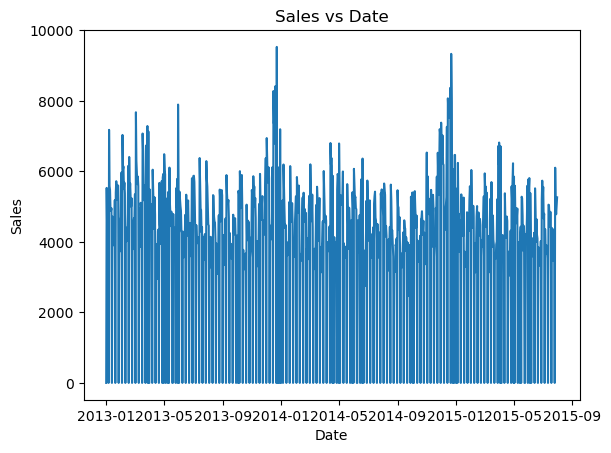

3945.704883227176
4057597.06364919


In [40]:
plt.figure()
plt.plot(ts.index, ts.values)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales vs Date")
plt.show()

mean = np.mean(ts.values)
variance = np.var(ts.values)

print(mean)
print(variance)

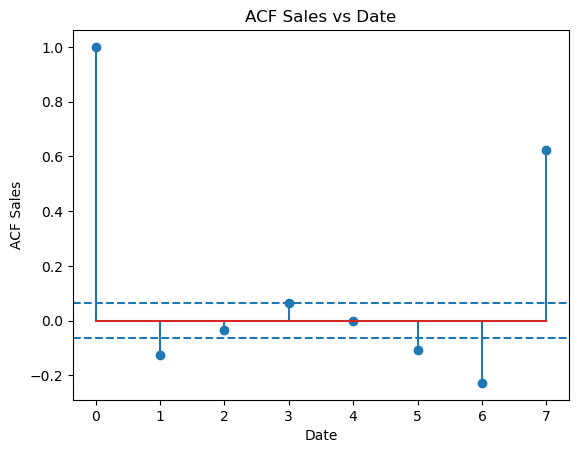

In [41]:
from statsmodels.tsa.stattools import acf

acf_values = acf(signal, nlags = 7)

lags = range(len(acf_values))

critical_value = 1.96 / np.sqrt(len(ts))

plt.figure()
plt.stem(lags, acf_values)
plt.xlabel("Date")
plt.axhline(critical_value,linestyle='--')
plt.axhline(-critical_value,linestyle='--')
plt.ylabel("ACF Sales")
plt.title("ACF Sales vs Date")
plt.show()

#### Strong autocorrelation as day 7 - seasonal likely, lets use Dicky fueller 

In [48]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.values)

print("ADF Statistic:" , result[0])
print("p-value:", result[1])

ADF Statistic: -4.368104368168495
p-value: 0.00033788346141424956


#### ADF test indicates that stationarity looks fine. Big spike at lag 7 in the ACF. We'll need to do SARIMA 